**FORS351 - Lab 3**
<br/>26th March 2026
*<br/>Theo Symonds - 790975290*

# Part I - Setup and Load Data

In [1]:
# Import and Authenticate GEE
import ee
import geemap

In [2]:
# Change project name to my google account
ee.Authenticate() #if error use: ee.Authenticate(force=True)
ee.Initialize(project='fors351labs-489406')
print("Accept Google permissions if prompted.")

Accept Google permissions if prompted.


In [3]:
#Connect to all landsat data for 2018 and 2019
dataset = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterDate(
    '2018-01-01', '2019-12-31'
)

In [4]:
# Mount Google Drive and set an output folder for saving figures,
print("Accept Google permissions if prompted.")
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

Accept Google permissions if prompted.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Preprocessing function
def preprocess_landsat8(image):
    # QA masks
    qa_mask = image.select('QA_PIXEL').bitwiseAnd(int('11111', 2)).eq(0)
    saturation_mask = image.select('QA_RADSAT').eq(0)

    # Apply scaling factors
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)

    return (
        image
        .addBands(optical, None, True)
        .addBands(thermal, None, True)
        .updateMask(qa_mask)
        .updateMask(saturation_mask)
    )

In [6]:
dataset_cleaned = dataset.map(preprocess_landsat8)

# Part II - Reading in Data from other Sources

## Task 1

In [7]:
# Drive folder with egojson file
geojson_path = '/content/drive/MyDrive/FORS351/'

# Full file path for geojson file
geojson = geojson_path + 'California_Historic_Fire_Perimeters_106541161897094478.geojson'

# Import geopandas
import geopandas as gpd

# Read in geojson
WoolseyFire_Perimeter = gpd.read_file(geojson)

#Converts the file to a GEE feature
WoolseyFire_Perimeter_gee = geemap.geopandas_to_ee(WoolseyFire_Perimeter)

# Prep feature to be used as clip
woolsey_geom = WoolseyFire_Perimeter_gee.geometry()

# Show map
Map = geemap.Map()
Map.centerObject(woolsey_geom, 10)
Map.addLayer(woolsey_geom, {}, 'Woolsey Fire Perimeter')
Map

Map(center=[34.11695185819203, -118.80021714375805], controls=(WidgetControl(options=['position', 'transparent…

## Task 2

In [8]:
#Compute NDVI formula
def calc_ndvi(image):
  ndvi_expression = "(NIR - Red) / (NIR + Red)"

  ndvi = image.expression(ndvi_expression,{
          'NIR': image.select('SR_B5'),
          'Red': image.select('SR_B4')}).rename('NDVI')

  image = image.addBands(ndvi)
  return image

#Visualization paramaters
ndvi_vis_params = {
    'min': 0,
    'max': 1,
    'dimensions': 1000,
    'palette': ['A50026', 'D73027', 'F46D43', 'FDAE61', 'FEE08B',
                'FFFFBF','D9EF8B','A6D96A','66BD63','1A9850']
}

# Cleaning dataset by median
image = calc_ndvi(dataset_cleaned.median()).clip(woolsey_geom)

# show ndvi map
Map = geemap.Map()
Map.centerObject(woolsey_geom, 10)
Map.addLayer(image.select('NDVI'), vis_params=ndvi_vis_params, name='NDVI')
Map.addLayer(woolsey_geom, {}, 'Woolsey Fire Perimeter')
Map

Map(center=[34.11695185819203, -118.80021714375805], controls=(WidgetControl(options=['position', 'transparent…

# Task 3

In [9]:
ndvi_collection = dataset_cleaned.map(calc_ndvi)

# Convert to dataframe only keeping nvdi and time
def compute_timeseries(ImageCollection, region):
    def per_image(img):
        mean_dict = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=30,
        )

        return ee.Feature(
            None,
            {
                'NDVI': mean_dict.get('NDVI'),
                'time': img.date().millis()
            }
        )

    return ee.FeatureCollection(ImageCollection.filterBounds(region).map(per_image))

ndvi_time_series = compute_timeseries(ndvi_collection, woolsey_geom)

ndvi_df = geemap.ee_to_df(ndvi_time_series)
ndvi_df = ndvi_df[['NDVI', 'time']]

ndvi_df.head()

,NDVI,time
0,NaN,1515004108315
1,0.392404,1516386500775
2,0.476062,1517768891762
3,0.472663,1519151286301
4,0.421124,1520533678017


In [10]:
# number of rows = number of NDVI days being exported to the data table
print(ndvi_time_series.size().getInfo())

132


In [11]:
import pandas as pd

#create a dataframe with NDVI is one column and time in the next column
ndvi_timeseries_df = geemap.ee_to_df(ndvi_time_series, ['NDVI', 'time'], remove_geom=True)

#specify the time units in your dataframe
ndvi_timeseries_df['time'] = pd.to_datetime(ndvi_timeseries_df['time'], unit='ms')

#Drop the NA values, which means there is no data available and sort by time
ndvi_timeseries_df = ndvi_timeseries_df.dropna().sort_values('time')
print(ndvi_timeseries_df)

         NDVI                    time
88   0.426618 2018-01-10 18:34:36.168
1    0.392404 2018-01-19 18:28:20.775
89   0.491231 2018-01-26 18:34:27.316
2    0.476062 2018-02-04 18:28:11.762
47   0.512856 2018-02-04 18:28:35.645
..        ...                     ...
130  0.368061 2019-11-29 18:34:50.106
43  -0.026556 2019-12-08 18:28:38.724
131  0.404673 2019-12-15 18:34:48.525
44   0.483066 2019-12-24 18:28:35.586
87   0.491590 2019-12-24 18:28:59.473

[109 rows x 2 columns]


# Task 4

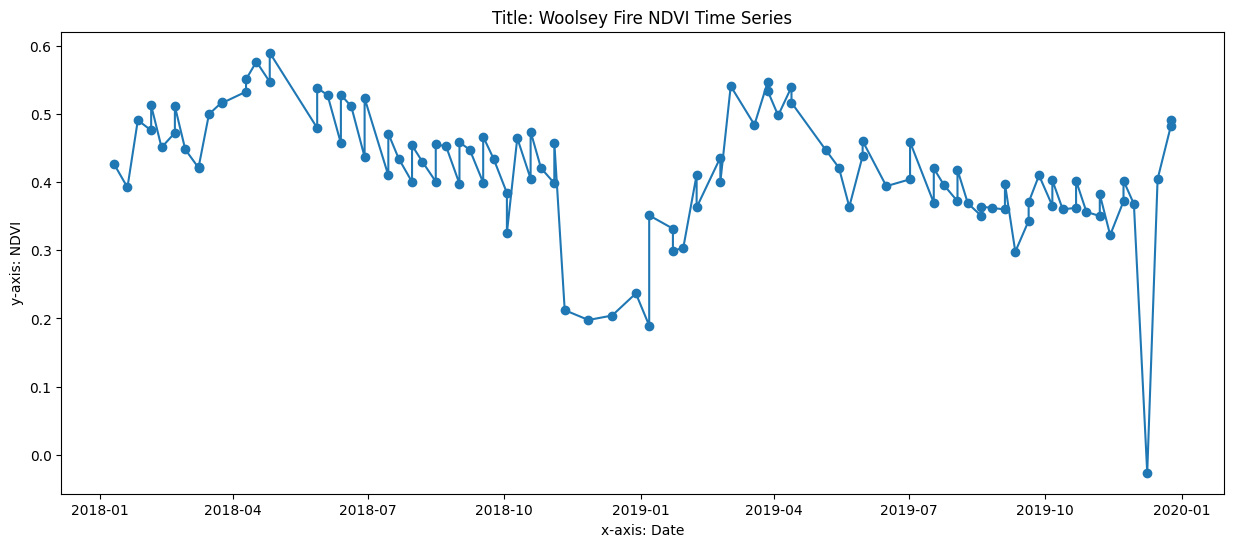

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.plot(ndvi_timeseries_df['time'], ndvi_timeseries_df['NDVI'],marker='o')
plt.xlabel('x-axis: Date')
plt.ylabel('y-axis: NDVI')
plt.title('Title: Woolsey Fire NDVI Time Series')
plt.show()

# Task 5

In [13]:
# Create new rectangle bounding box
baseline_geom = ee.Geometry.Rectangle([
    -118.66550201118918,
    34.06230249563295,
    -118.52504359504627,
    34.13089722406558
])

baseline_timeseries = compute_timeseries(ndvi_collection, baseline_geom)

baseline_timeseries_df = geemap.ee_to_df(baseline_timeseries, ['NDVI', 'time'], remove_geom=True)

baseline_timeseries_df['time'] = pd.to_datetime(baseline_timeseries_df['time'], unit='ms')
baseline_timeseries_df = baseline_timeseries_df.dropna().sort_values('time')

#Print to see the dataframe your timeseries
print(baseline_timeseries_df)

        NDVI                    time
1   0.980146 2018-01-19 18:28:20.775
2   0.553662 2018-02-04 18:28:11.762
47  0.561056 2018-02-04 18:28:35.645
3   0.549153 2018-02-20 18:28:06.301
48  0.551819 2018-02-20 18:28:30.196
..       ...                     ...
42  0.568860 2019-11-22 18:28:39.085
85  0.573985 2019-11-22 18:29:02.972
43  0.147280 2019-12-08 18:28:38.724
44  0.641314 2019-12-24 18:28:35.586
87  0.610421 2019-12-24 18:28:59.473

[67 rows x 2 columns]


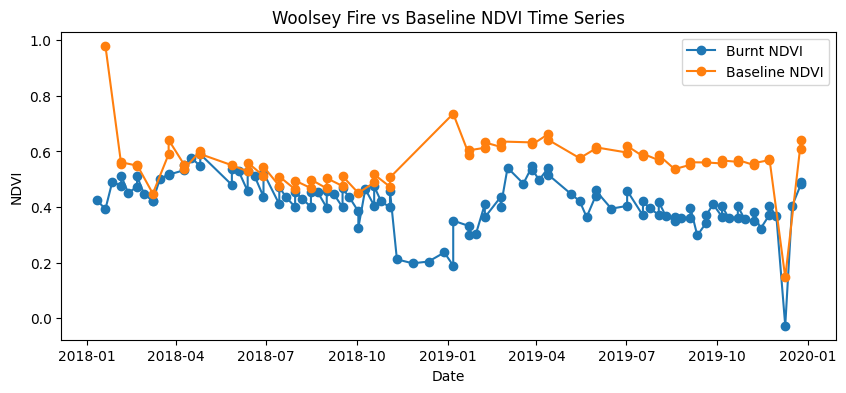

In [14]:
import matplotlib.pyplot as plt

# Overlay two plots of NDVI for burned area and the baseline
plt.figure(figsize=(10, 4))
plt.plot(ndvi_timeseries_df['time'], ndvi_timeseries_df['NDVI'],marker='o')
plt.plot(baseline_timeseries_df['time'], baseline_timeseries_df['NDVI'],marker='o')
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('Woolsey Fire vs Baseline NDVI Time Series')
plt.legend(['Burnt NDVI', 'Baseline NDVI'])
plt.show()

# Task 6

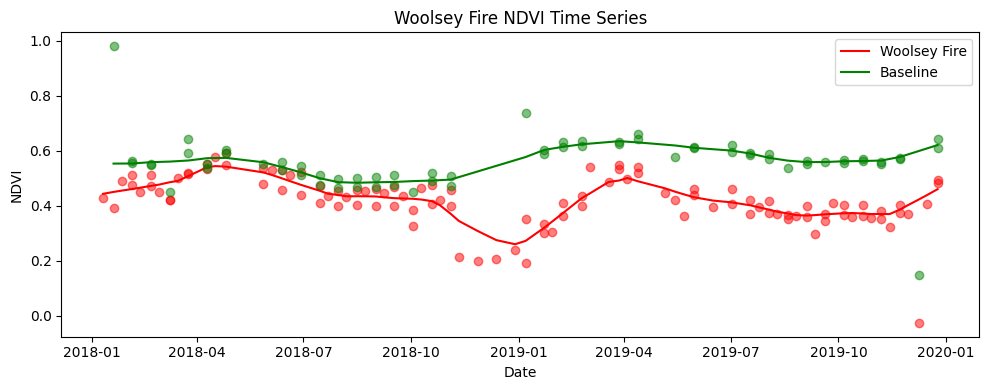

In [15]:
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

def lowess_smooth(df, var, frac=0.15):
    smoothed = lowess(
        endog=df[var],
        exog=df['time'].astype('int64'),
        frac=frac,
        return_sorted=False
    )
    return smoothed

ndvi_timeseries_df['NDVI_smooth'] = lowess_smooth(ndvi_timeseries_df, 'NDVI')
baseline_timeseries_df['NDVI_smooth'] = lowess_smooth(baseline_timeseries_df, 'NDVI')

plt.figure(figsize=(10, 4))
plt.plot(ndvi_timeseries_df['time'], ndvi_timeseries_df['NDVI'],
         marker='o', linestyle='None', color='red', alpha=0.5, label='')
plt.plot(ndvi_timeseries_df['time'], ndvi_timeseries_df['NDVI_smooth'],
         linestyle='-', color='red', label='Woolsey Fire')
plt.plot(baseline_timeseries_df['time'], baseline_timeseries_df['NDVI'],
         marker='o', linestyle='None', color='green', alpha=0.5, label='')
plt.plot(baseline_timeseries_df['time'], baseline_timeseries_df['NDVI_smooth'],
         linestyle='-', color='green', label='Baseline')
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('Woolsey Fire vs Baseline NDVI Time Series')
plt.tight_layout()
plt.legend()
plt.show()

# Task 7

In [16]:
#Change directory to a folder on your drive where you put the GeoJSON file
#NOTE YOURS WILL BE DIFFERENT THAN MINE, everying after My Drive/ is your own
#directory. Make sure it ends with a backslash.
geojson_path = '/content/drive/MyDrive/FORS351/'

#This is where it calls the file you downloaded and moved into your Google Drive
#Your file name may be different than mine, so you might have to change this
geojson = geojson_path + 'California_Historic_Fire_Perimeters_-3061168889927148014.geojson'

#This imports a geospatial package called 'geopandas' and then plots the fire permiter
import geopandas as gpd

# Reads in the file, note I'm changing the name to Donnell!
DonnellFire_Perimeter = gpd.read_file(geojson)

#Converts the file to a GEE feature
DonnellFire_Perimeter_gee = geemap.geopandas_to_ee(DonnellFire_Perimeter)

#Turns the feature into a geometry object which we can use to clip our data
donnell_geom = DonnellFire_Perimeter_gee.geometry()

#Create your map of the Donnell Fire Perimeter
Map = geemap.Map()
Map.centerObject(donnell_geom, 10)
Map.addLayer(donnell_geom, {}, 'Donnell Fire Perimeter')
Map

Map(center=[38.37738981168382, -119.82185268461248], controls=(WidgetControl(options=['position', 'transparent…

In [17]:
#Connect to all landsat data for 2018 and 2019 - or change to your date of
#interest. Note the Donnell fire occured in 2018, so I want to capture the fire
#year and recovery immediately after
dataset = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterDate(
    '2018-01-01', '2019-12-31'
)

# Mount Google Drive and set an output folder for saving figures,
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

# Preprocessing function
def preprocess_landsat8(image):
    # QA masks
    qa_mask = image.select('QA_PIXEL').bitwiseAnd(int('11111', 2)).eq(0)
    saturation_mask = image.select('QA_RADSAT').eq(0)

    # Apply scaling factors
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)

    return (
        image
        .addBands(optical, None, True)
        .addBands(thermal, None, True)
        .updateMask(qa_mask)
        .updateMask(saturation_mask)
    )

dataset_cleaned = dataset.map(preprocess_landsat8)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
#Visualization paramaters
ndvi_vis_params = {
    'min': 0,
    'max': 1,
    'dimensions': 1000,
    'palette': ['A50026', 'D73027', 'F46D43', 'FDAE61', 'FEE08B',
                'FFFFBF','D9EF8B','A6D96A','66BD63','1A9850']
}

# Cleaning dataset by median
image = calc_ndvi(dataset_cleaned.median()).clip(donnell_geom)

# show ndvi map
Map = geemap.Map()
Map.centerObject(donnell_geom, 10)
Map.addLayer(image.select('NDVI'), vis_params=ndvi_vis_params, name='NDVI')
Map.addLayer(donnell_geom, {}, 'Donnell Fire Perimeter')
Map

Map(center=[38.37738981168382, -119.82185268461248], controls=(WidgetControl(options=['position', 'transparent…

In [18]:
#Compute NDVI for your images, by first defining a function
# Band 5 is the NIR band from Landsat 8 and Band 4 is the Red
def calc_ndvi(image):
  ndvi_expression = "(NIR - Red) / (NIR + Red)"

  ndvi = image.expression(ndvi_expression,{
          'NIR': image.select('SR_B5'),
          'Red': image.select('SR_B4')}).rename('NDVI')

  image = image.addBands(ndvi)
  return image

#You have already defined the NDVI collection above, but we will do it again here,
#note that I am changing the bottom line of code to make sure I am computing
#the timeseries of my Donnell fire. You will need to change this to match yours

ndvi_collection = dataset_cleaned.map(calc_ndvi)

# The last map you made only returns one timestamp because it's using reducer
# over the entire timeseries.
def compute_timeseries(ImageCollection, region):
    def per_image(img):
        mean_dict = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=30,
        )

        return ee.Feature(
            None,
            {
                'NDVI': mean_dict.get('NDVI'),
                'time': img.date().millis()
            }
        )

    return ee.FeatureCollection(ImageCollection.filterBounds(region).map(per_image))

ndvi_time_series = compute_timeseries(ndvi_collection, donnell_geom)

#print the data table
print(ndvi_time_series.size().getInfo())

131


In [19]:
#Now create your data frame below by cleaning it, just like you did for the
#Woolsely fire, but now for the new fire. Nothing needs to change in this code
#but note these variables will now be overwritten.

import pandas as pd

#create a dataframe with NDVI is one column and time in the next column
ndvi_timeseries_df = geemap.ee_to_df(ndvi_time_series, ['NDVI', 'time'], remove_geom=True)

#specify the time units in your dataframe
ndvi_timeseries_df['time'] = pd.to_datetime(ndvi_timeseries_df['time'], unit='ms')

#Drop the NA values, which means there is no data available and sort by time
ndvi_timeseries_df = ndvi_timeseries_df.dropna().sort_values('time')

#print the dataframe
print(ndvi_timeseries_df)

         NDVI                    time
88   0.833236 2018-01-01 18:39:39.007
45   1.100707 2018-01-26 18:33:39.538
90   0.625444 2018-02-02 18:39:22.225
2    0.574972 2018-02-11 18:33:08.867
46   0.626065 2018-02-11 18:33:32.749
..        ...                     ...
42   0.068647 2019-11-29 18:33:38.442
86   0.019771 2019-11-29 18:34:02.333
130  0.007937 2019-12-06 18:39:48.882
43   0.045929 2019-12-15 18:33:36.856
87  -0.030822 2019-12-15 18:34:00.747

[112 rows x 2 columns]


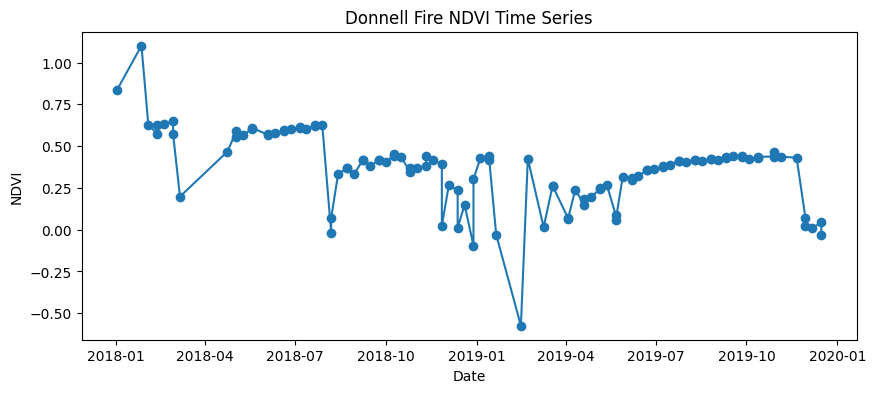

In [20]:
#Now make a plot of NDVI for your fire of interest, change the title of your
#fire so it's not called Lolo - because that's the example here

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(ndvi_timeseries_df['time'], ndvi_timeseries_df['NDVI'], marker='o')

plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('Donnell Fire NDVI Time Series')

plt.show()

In [21]:
#This is a polygon I created around a baseline I knew didn't burn, but you can
#modify this code for a simple rectangle and changing the code to ee.Geometry.Rectangle
baseline_geom = ee.Geometry.Rectangle([
    -120.17681311037637,
    38.50584373060667,
    -119.90897143263585,
    38.612982373112715
])

baseline_timeseries = compute_timeseries(ndvi_collection, baseline_geom)

baseline_timeseries_df = geemap.ee_to_df(baseline_timeseries, ['NDVI', 'time'], remove_geom=True)

baseline_timeseries_df['time'] = pd.to_datetime(baseline_timeseries_df['time'], unit='ms')
baseline_timeseries_df = baseline_timeseries_df.dropna().sort_values('time')

#Print to see the dataframe your timeseries
print(baseline_timeseries_df)

        NDVI                    time
0   0.462928 2018-01-01 18:39:39.007
2   0.336140 2018-02-02 18:39:22.225
3   0.507397 2018-02-18 18:39:17.124
4   0.060562 2018-03-06 18:39:09.170
6   0.220843 2018-04-23 18:38:44.041
7   0.452975 2018-05-09 18:38:34.781
8   0.462933 2018-06-10 18:38:20.231
9   0.479954 2018-06-26 18:38:30.862
10  0.484756 2018-07-12 18:38:39.046
11  0.488737 2018-07-28 18:38:45.689
12  0.474392 2018-08-13 18:38:55.157
13  0.461811 2018-08-29 18:39:02.419
14  0.415692 2018-09-14 18:39:07.251
15  0.477192 2018-09-30 18:39:14.057
16  0.492974 2018-10-16 18:39:20.894
17  0.285076 2018-11-01 18:39:24.978
18  0.499340 2018-11-17 18:39:26.220
19  0.154146 2018-12-03 18:39:24.493
20  0.454999 2018-12-19 18:39:22.526
21  0.250125 2019-01-04 18:39:22.062
22 -0.034442 2019-01-20 18:39:18.816
23  0.027018 2019-02-05 18:39:15.816
24  0.258540 2019-02-21 18:39:13.116
25  0.063254 2019-03-09 18:39:07.888
26  0.196542 2019-03-25 18:39:04.088
27  0.171732 2019-04-10 18:38:59.595
2

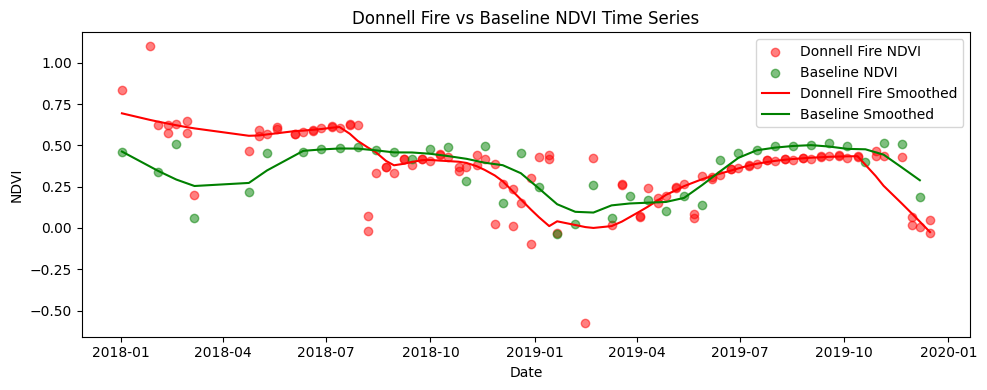

In [22]:
from statsmodels.nonparametric.smoothers_lowess import lowess

def lowess_smooth(df, var, frac=0.15):
    smoothed = lowess(
        endog=df[var],
        exog=df['time'].astype('int64'),
        frac=frac,
        return_sorted=False
    )
    return smoothed

ndvi_timeseries_df['NDVI_smooth'] = lowess_smooth(ndvi_timeseries_df, 'NDVI')
baseline_timeseries_df['NDVI_smooth'] = lowess_smooth(baseline_timeseries_df, 'NDVI')

plt.figure(figsize=(10, 4))

# Raw points
plt.scatter(ndvi_timeseries_df['time'], ndvi_timeseries_df['NDVI'],
            color='red', alpha=0.5, label='Donnell Fire NDVI')
plt.scatter(baseline_timeseries_df['time'], baseline_timeseries_df['NDVI'],
            color='green', alpha=0.5, label='Baseline NDVI')

# Smoothed trend lines
plt.plot(ndvi_timeseries_df['time'], ndvi_timeseries_df['NDVI_smooth'],
         linestyle='-', color='red', label='Donnell Fire Smoothed')
plt.plot(baseline_timeseries_df['time'], baseline_timeseries_df['NDVI_smooth'],
         linestyle='-', color='green', label='Baseline Smoothed')

plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('Donnell Fire vs Baseline NDVI Time Series')
plt.tight_layout()
plt.legend()
plt.show()

### Observations in timeseries
The wildfire examined in the above timeseries is of the Donnell Fire that occured south of Lake Tahoe in California. The cause was a campfire and ended up burning over 36k acres.
The fire first happened towards the end of summer, starting on August 1st 2018.
The recovery period appears to show a noticeable drop in NDVI right after the fire in August, and then reaching its lowest smoothed values in the winter of 2019. After that, NDVI gradually increased throughout 2019, which suggests vegetation recovery was underway less than a year after the fire. However, by the end of 2019 the burned area still generally appears more variable and lower than the baseline, so recovery looks partial rather than complete over this time period.